# Full EDA — Insurance Dataset
Comprehensive analysis with proper plotting


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('insurance.csv')
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

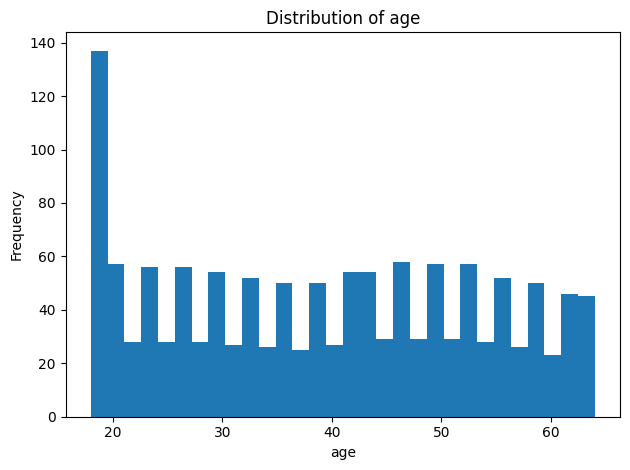

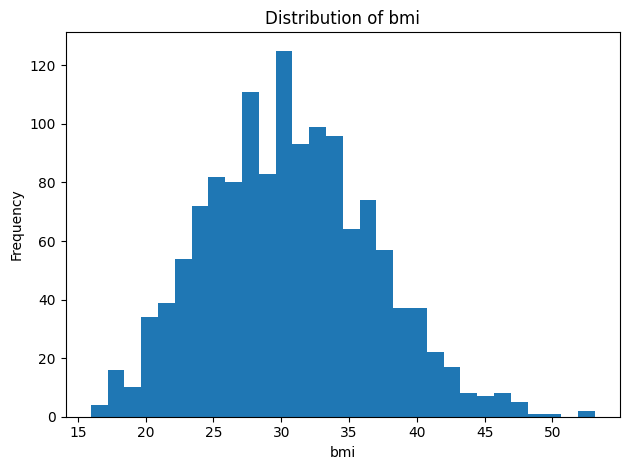

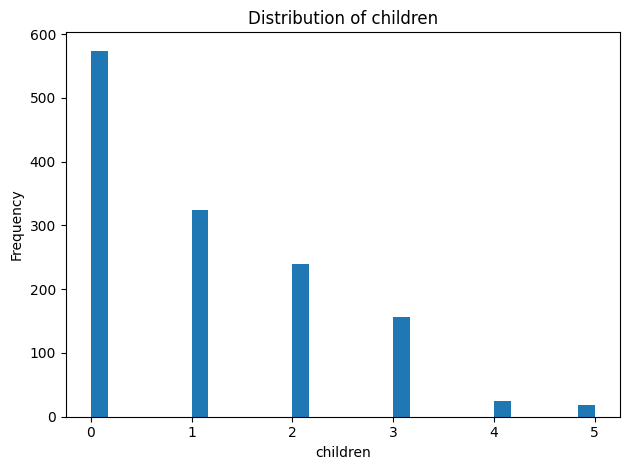

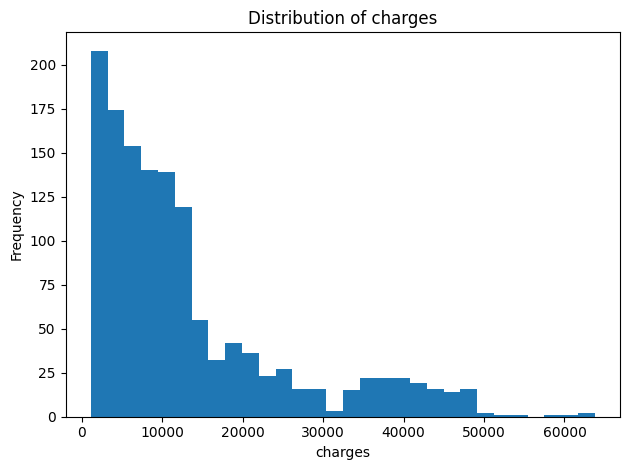

In [4]:
num_cols = ['age','bmi','children','charges']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

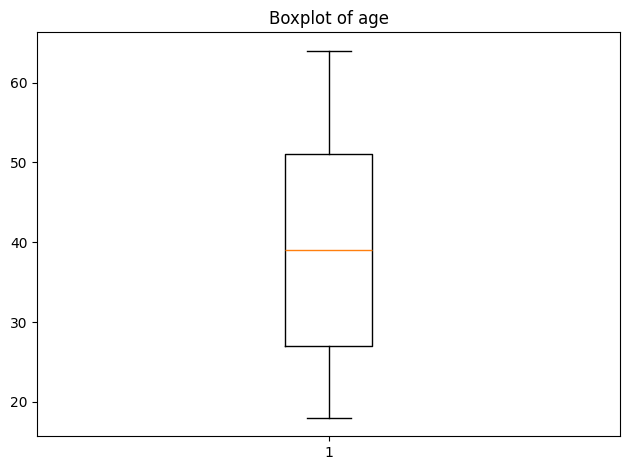

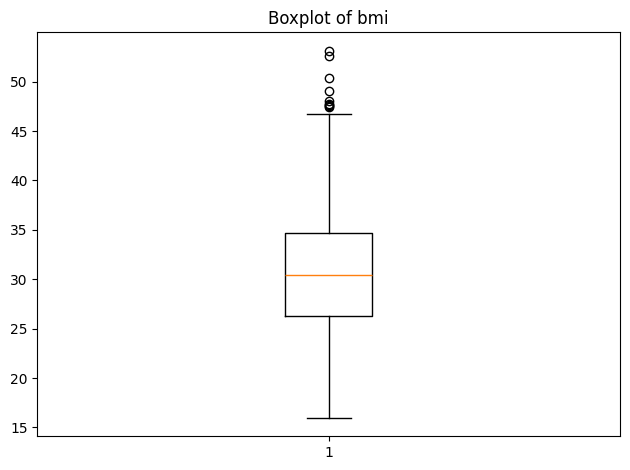

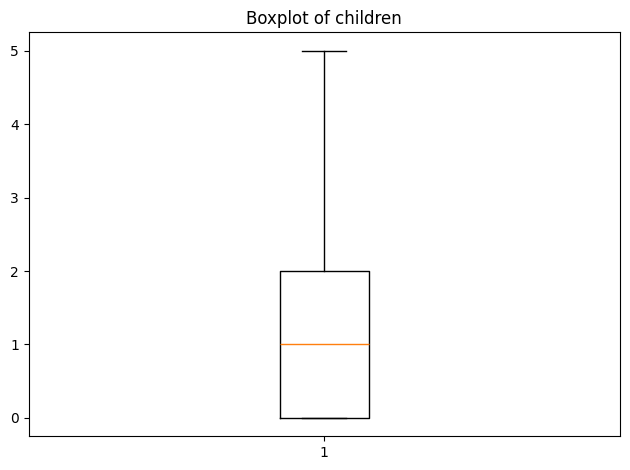

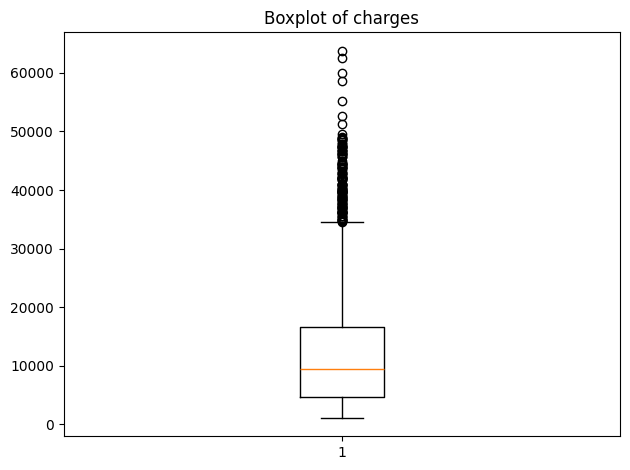

In [5]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

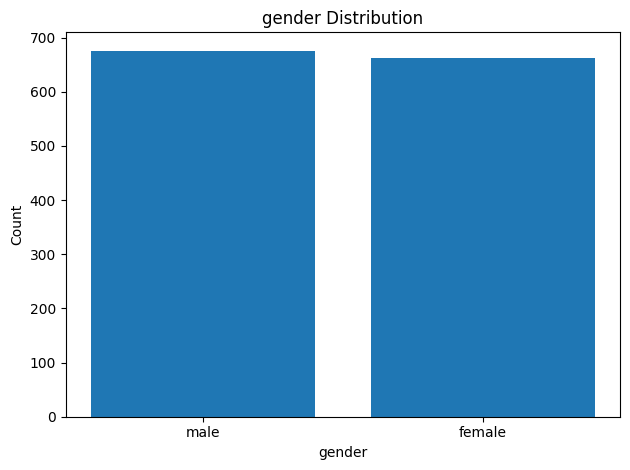

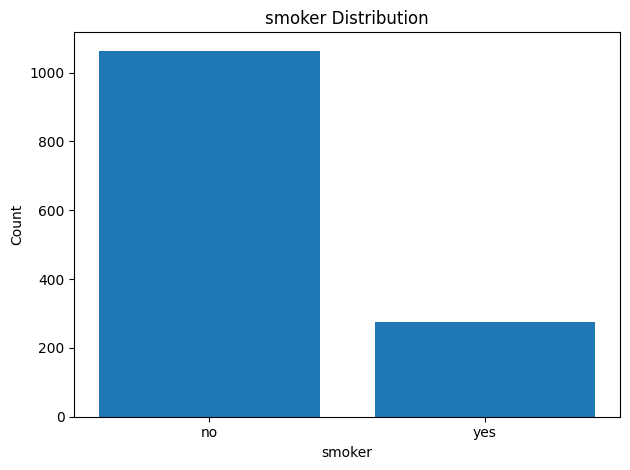

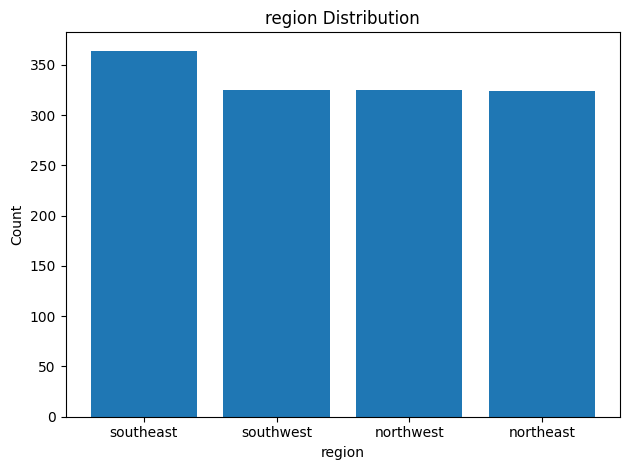

In [6]:
cat_cols = ['gender','smoker','region']
for col in cat_cols:
    counts = df[col].value_counts()
    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

/var/folders/_5/wx3bhmf91dq3fv1bjwmpdlzc0000gn/T/ipykernel_91607/100399453.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups.groups.keys())


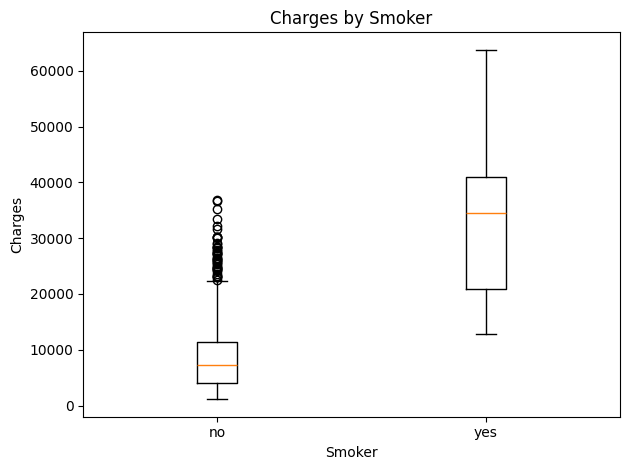

In [7]:
groups = df.groupby('smoker')['charges']
data = [groups.get_group(x) for x in groups.groups]
plt.figure()
plt.boxplot(data, labels=groups.groups.keys())
plt.title('Charges by Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

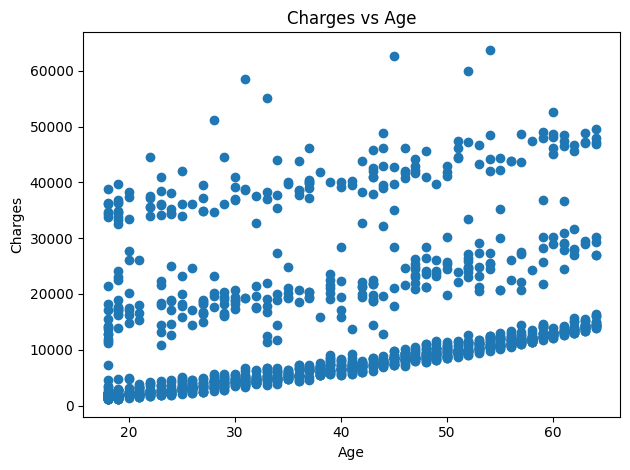

In [8]:
plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title('Charges vs Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

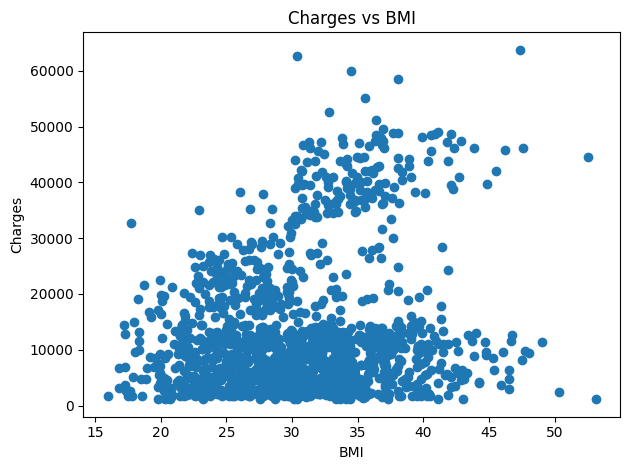

In [9]:
plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title('Charges vs BMI')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

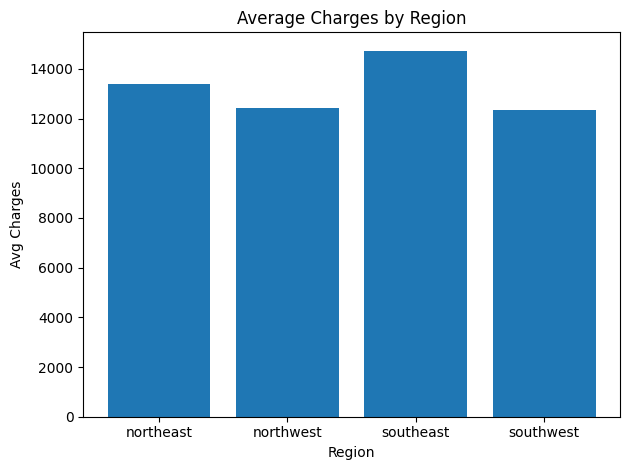

In [10]:
region_avg = df.groupby('region')['charges'].mean()
plt.figure()
plt.bar(region_avg.index, region_avg.values)
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Avg Charges')
plt.tight_layout()
plt.show()

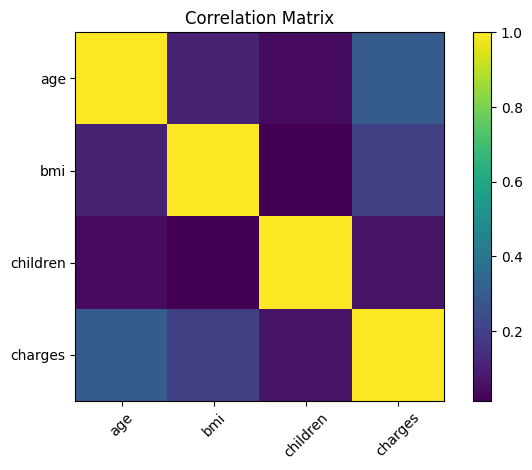

In [11]:
corr = df[['age','bmi','children','charges']].corr()
plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()

## Key Insights
- Smoking has a major impact on charges
- Charges increase with age
- BMI shows moderate relationship
- Region differences are smaller compared to smoking effect
